# Tomás Solano, InZenFenix, IIT414W, 20-04-2026

# CELL 1. Reproducibility, Libraries and Cache

In [2]:
# ── Cell 1: Reproducibility Header ────────────────────────────────────────────
# Every notebook in IIT414W starts here. Do not skip this block.

import sys, random
import numpy as np
import warnings
import platform

RANDOM_SEED = 414  # Course constant. Do not change.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

# Environment check
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'Seed    : {RANDOM_SEED}')
print("\nSystem: " + platform.system())
print("Distro: " + platform.release())

Python  : 3.14.3
NumPy   : 2.4.4
Seed    : 414

System: Linux
Distro: 6.19.11-201.nobara.fc43.x86_64


In [3]:
# ── Cell 2: Dependency Guard ───────────────────────────────────────────────
# Ensures all required packages are installed in the active kernel.
# Safe to re-run: pip will skip already-installed packages.

import importlib, subprocess, sys

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
    'xgboost': 'xgboost'
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Done. Packages installed successfully.')
else:
    print('All required packages already installed ✓')

# ── Library Imports ───────────────────────────────────────────────
import os                        # Working directory checks
import subprocess                # Git command checks
import importlib                 # Runtime dependency checks
import numpy as np               # Numeric support
import pandas as pd              # Tables and diagnostics
import fastf1                    # Formula 1 data access
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression # Model
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( #Metrics
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc
)


print(f'fastf1  : {fastf1.__version__}')
print(f'pandas  : {pd.__version__}')

All required packages already installed ✓
fastf1  : 3.8.2
pandas  : 2.3.3


## IMPORTANT INFORMATION

- We are trying to predict if a Driver ends top 10 by the end of the race.
- Last time we created a heuristic model with the racer's team and compare it with simple models.
- This time we are creating 5 models, 2 baselines and 3 "improved" models.
- The main metric will be macro F1 (since our target is a classification)

## CELL 2.0 -- OBTAINING DATA

- We are gonna use 22 rounds for 2024 and 5 for 2025 (train and test respectively)

In [4]:
def get_session_data(year, rounds):
    data_frames = []
    for r in range(1, rounds + 1):
        try:
            session = fastf1.get_session(year, r, 'Q')
            session.load(telemetry=False, weather=False, messages=False)
            
            res = session.results.copy()
            df_round = res[['FullName', 'Position', 'TeamName', 'Abbreviation']].copy()

            # Metadata
            df_round['Round'] = r
            df_round['Year'] = year
            df_round['Circuit'] = session.event.get('EventName', f'Round_{r}')

            # Raw Lap Times (in seconds)
            q_cols = [c for c in ['Q1', 'Q2', 'Q3'] if c in res.columns]
            if q_cols:
                # Convert to seconds immediately
                for col in q_cols:
                    df_round[col] = res[col].dt.total_seconds()
                df_round['BestLapTime_Raw'] = df_round[q_cols].min(axis=1)
            else:
                df_round['BestLapTime_Raw'] = float('nan')

            # Q Stage Reached
            def q_stage_reached(row):
                if pd.notna(res.loc[row.name, 'Q3']) if 'Q3' in res.columns else False: return 3
                if pd.notna(res.loc[row.name, 'Q2']) if 'Q2' in res.columns else False: return 2
                return 1
            df_round['QStageReached_Raw'] = df_round.apply(q_stage_reached, axis=1)

            data_frames.append(df_round)
            print(f"✓ Loaded {year} Round {r}")
        except Exception as e:
            print(f"✗ Skipping {year} Round {r}: {e}")

    return pd.concat(data_frames, ignore_index=True) if data_frames else pd.DataFrame()

def add_agg_features(df):
    """
    Computes features based strictly on HISTORICAL data.
    The model only sees what happened before the current qualifying lights go green.
    """
    # Ensure chronological order
    df = df.sort_values(['Year', 'Round', 'Position'])
    
    # --- 1. Define the Target ---
    # This is what we want to predict (current race result)
    df['target_top10'] = (pd.to_numeric(df['Position'], errors='coerce') <= 10).astype(int)

    # --- 2. Season-Relative Performance (Shifted) ---
    # We calculate the lap delta WITHIN each round first
    df['LapDelta_Raw'] = df.groupby(['Year', 'Round'])['BestLapTime_Raw'].transform(
        lambda x: x - x.min()
    ).fillna(5.0)

    # --- 3. Feature Engineering (The "Past Info" only) ---
    group_driver = df.groupby(['FullName'])
    group_team = df.groupby(['TeamName', 'Year']) # Teams change cars every year

    # Driver Form: Rolling top 10 rate from previous races
    df['driver_form'] = group_driver['target_top10'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )

    # Seasonal Consistency: Avg lap delta in the current season so far
    # We group by Year here so 2024 pace doesn't skew 2025's new car pace
    df['avg_delta_season'] = df.groupby(['FullName', 'Year'])['LapDelta_Raw'].transform(
        lambda x: x.shift(1).expanding().mean()
    )

    # Team Strength: Avg finishing position this season
    df['team_strength'] = group_team['Position'].transform(
        lambda x: x.shift(1).expanding().mean()
    )

    # Experience: Past Q-Stage performance
    df['prev_q_stage'] = group_driver['QStageReached_Raw'].transform(lambda x: x.shift(1))

    # Fill NaNs (Start of season/Career)
    df = df.fillna({
        'driver_form': 0.5,
        'team_strength': 10.5,
        'avg_delta_season': 2.0,
        'prev_q_stage': 1
    })

    # --- 4. Safety Drop ---
    # We remove the "Raw" current-session columns so the model CANNOT use them to cheat
    cols_to_drop = ['BestLapTime_Raw', 'QStageReached_Raw', 'LapDelta_Raw']
    return df.drop(columns=cols_to_drop)


# 1. DATA ACQUISITION
# Training on 2024, Testing on early 2025 (Temporal Split)
print("Downloading F1 Data...")

#We add the aggregated features separately to prevent temporal leakage
train_raw = add_agg_features(get_session_data(2024, 22))
test_raw = add_agg_features(get_session_data(2025, 5))

#FULL_DF Contains all data, good for heuristic baselines
#HOWEVER When working with the models It will be split back into train and test when scaling
full_df = pd.concat([train_raw, test_raw], ignore_index=True)


display(full_df)

req         WARNING 	DEFAULT CACHE ENABLED! (36.08 MB) /home/inzenfenix/.cache/fastf1


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


✓ Loaded 2024 Round 1


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


✓ Loaded 2024 Round 2


...

req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '16', '12', '10', '4', '1', '55', '44', '22', '7', '6', '14', '31', '23', '27', '30', '5', '18', '87']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


✓ Loaded 2025 Round 4


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '63', '16', '12', '55', '44', '22', '10', '4', '23', '30', '14', '6', '87', '18', '7', '27', '31', '5']


✓ Loaded 2025 Round 5


,FullName,Position,TeamName,Abbreviation,Round,Year,Circuit,Q1,Q2,Q3,target_top10,driver_form,avg_delta_season,team_strength,prev_q_stage
0,Max Verstappen,1.0,Red Bull Racing,VER,1,2024,Bahrain Grand Prix,90.031,89.374,89.179,1,0.5,2.00000,10.500000,1.0
1,Charles Leclerc,2.0,Ferrari,LEC,1,2024,Bahrain Grand Prix,90.243,89.165,89.407,1,0.5,2.00000,10.500000,1.0
2,George Russell,3.0,Mercedes,RUS,1,2024,Bahrain Grand Prix,90.350,89.922,89.485,1,0.5,2.00000,10.500000,1.0
3,Carlos Sainz,4.0,Ferrari,SAI,1,2024,Bahrain Grand Prix,89.909,89.573,89.507,1,0.5,2.00000,2.000000,1.0
4,Sergio Perez,5.0,Red Bull Racing,PER,1,2024,Bahrain Grand Prix,90.221,89.932,89.537,1,0.5,2.00000,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,Lance Stroll,16.0,Aston Martin,STR,5,2025,Saudi Arabian Grand Prix,88.645,NaN,NaN,0,0.0,1.78375,14.444444,1.0
535,Jack Doohan,17.0,Alpine,DOO,5,2025,Saudi Arabian Grand Prix,88.739,NaN,NaN,0,0.0,1.49200,12.444444,2.0
536,Nico Hulkenberg,18.0,Kick Sauber,HUL,5,2025,Saudi Arabian Grand Prix,88.782,NaN,NaN,0,0.0,1.57175,16.250000,1.0
537,Esteban Ocon,19.0,Haas F1 Team,OCO,5,2025,Saudi Arabian Grand Prix,89.092,NaN,NaN,0,0.0,1.62525,16.000000,1.0


## CELL 2.1 -- HEUSTERIC BASELINE

- Baselines only use one feature to work (position, team, etc.), however the temporal set is the same for both the baseline and the models

### Heuristic 1: "**Your predicted grid position is the average of your last 3 qualifying sessions**"

- Leakage Prevention: Ensures no leakage by shifting BEFORE calculating the rolling mean.
- Type of baseline: Form (Looking at recent history). 

In [5]:
# ---- HEURISTIC 1 MODEL -----

# 1. HEURISTIC FEATURE ENGINEERING
def apply_heuristic(df):
    # Sort by time to prevent leakage
    df = df.sort_values(['FullName', 'Year', 'Round'])
    
    # Create the 'Shift' (The Firewall)
    # This moves the result of the previous race to the current row
    df['prev_pos'] = df.groupby('FullName')['Position'].shift(1)
    
    # Calculate 3-race rolling average of PREVIOUS performances
    df['h_avg_pos'] = df.groupby('FullName')['prev_pos'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
    
    # Fill gaps for new drivers with the grid mid-point
    df['h_avg_pos'] = df['h_avg_pos'].fillna(10.5)
    
    # TARGET: Top-10 Finish (1 if Position <= 10, else 0)
    df['target_top10'] = (df['Position'] <= 10).astype(int)
    
    # HEURISTIC PREDICTION: Predicted to be in Top 10 if average pos <= 10
    df['pred_top10'] = (df['h_avg_pos'] <= 10).astype(int)
    
    # SCORING PROBABILITY: Inverted average for ROC-AUC/PR (Lower rank = higher 'score')
    df['h_score'] = 1 / df['h_avg_pos']
    
    return df

processed_df = apply_heuristic(full_df)

# 2. TEMPORAL EVALUATION
test_final = processed_df[processed_df['Year'] == 2025].copy()

train_final = processed_df[processed_df['Year'] == 2024].copy()

def get_scores(y_true, y_pred, y_score):
    return {
        "F1 (Macro)": f1_score(y_true, y_pred, average='macro'),
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC (Avg Precision)": average_precision_score(y_true, y_score)
    }

# Score the Test Set 
test_h_results = get_scores(test_final['target_top10'], 
                            test_final['pred_top10'], 
                            test_final['h_score'])

# Score the Train Set 
train_h_results = get_scores(train_final['target_top10'], 
                     train_final['pred_top10'], 
                     train_final['h_score'])


# 4. OUTPUT RESULTS
print("\n--- First Heuristic Baseline: 3-Race Rolling Average ---")

print("\nTRAINING METRIC")
for metric, value in train_h_results.items():
    print(f"{metric:25}: {value:.4f}")

print("\nTEST METRIC")
for metric, value in test_h_results.items():
    print(f"{metric:25}: {value:.4f}")

# Sample for verification
print("\nSample Predictions (Top 10 Prediction):")
print(test_final[['FullName', 'Position', 'h_avg_pos', 'pred_top10']].head(10))


--- First Heuristic Baseline: 3-Race Rolling Average ---

TRAINING METRIC
F1 (Macro)               : 0.7689
Accuracy                 : 0.7699
ROC-AUC                  : 0.8342
PR-AUC (Avg Precision)   : 0.8229

TEST METRIC
F1 (Macro)               : 0.7689
Accuracy                 : 0.7700
ROC-AUC                  : 0.8858
PR-AUC (Avg Precision)   : 0.9041

Sample Predictions (Top 10 Prediction):
                  FullName  Position  h_avg_pos  pred_top10
444        Alexander Albon       6.0  11.333333           0
468        Alexander Albon      10.0  10.333333           0
487        Alexander Albon       9.0  11.333333           0
513        Alexander Albon      15.0   8.333333           1
529        Alexander Albon      11.0  11.333333           0
454  Andrea Kimi Antonelli      16.0  10.500000           0
466  Andrea Kimi Antonelli       8.0  16.000000           0
448           Carlos Sainz      10.0   5.666667           1
473           Carlos Sainz      15.0   8.666667           1

### Heuristic 2: "**If you drive for Red Bull, Ferrari, or McLaren, you will almost always be in the Top 10, regardless of your last three races.**"

- Leakage Prevention: Using grid position at qualifying, to predict the grid position at the race (temporal safe-guard).
- Type of baseline: Constructor (the car itself). 

In [6]:
def apply_constructor_baseline(full_df):
    """
    Heuristic 2: Constructor-Based Prediction (Expanding Window).
    Ensures that a prediction for 'Race 10' only uses averages from 'Races 1-9'.
    """
    # 1. Ensure chronological order
    df = full_df.sort_values(['Year', 'Round', 'TeamName']).copy()
    
    # 2. Calculate the 'Expanding Mean' per Team
    # .shift(1) is the "Firewall": it ensures we don't include the current race in the average
    df['team_avg_to_date'] = df.groupby('TeamName')['Position'].transform(
        lambda x: x.shift(1).expanding().mean()
    )
    
    # 3. Handle the "First Race" problem
    # If a team has no history yet, we assume the grid midpoint (10.5)
    df['team_avg_to_date'] = df['team_avg_to_date'].fillna(10.5)
    
    # 4. Binary Classification: If team avg <= 10, predict 1 (Top 10)
    df['pred_constructor'] = (df['team_avg_to_date'] <= 10).astype(int)
    
    # 5. Probability Score (for ROC-AUC): Inverted team average
    df['c_score'] = 1 / df['team_avg_to_date']
    
    return df

# --- Execution ---
# Run this on your combined dataframe BEFORE splitting into Train/Test
processed_df = apply_constructor_baseline(full_df)

# Now split them for scoring
train_final = processed_df[processed_df['Year'] == 2024].copy()
test_final = processed_df[processed_df['Year'] == 2025].copy()

# Score the Training Set (This will now be HONEST)
train_c_results = get_scores(train_final['target_top10'], 
                             train_final['pred_constructor'], 
                             train_final['c_score'])

# Score the Test Set (This is what goes in your Comparison Table)
test_c_results = get_scores(test_final['target_top10'], 
                            test_final['pred_constructor'], 
                            test_final['c_score'])

print("\n--- Baseline 2: Constructor Tier ---")
print("\nTEST METRIC")
for metric, value in test_c_results.items():
    print(f"{metric:25}: {value:.4f}")

print("\nTRAIN METRIC")
for metric, value in train_c_results.items():
    print(f"{metric:25}: {value:.4f}")


--- Baseline 2: Constructor Tier ---

TEST METRIC
F1 (Macro)               : 0.8098
Accuracy                 : 0.8100
ROC-AUC                  : 0.8128
PR-AUC (Avg Precision)   : 0.8464

TRAIN METRIC
F1 (Macro)               : 0.7779
Accuracy                 : 0.7790
ROC-AUC                  : 0.8362
PR-AUC (Avg Precision)   : 0.8075


## CELL 2.2: MODELS

### 2.2.1: Scaler

- First we scale the data (based on train data)

In [7]:
# 1. DEFINE COLUMN GROUPS BASED ON YOUR IMAGE
# These are the numbers that need to be "Standardized" (Mean=0, Std=1)
numeric_features = [
    'Round',            # Current round number (helps capture season progression)
    'driver_form',      # Rolling Top 10 rate from previous 5 races
    'team_strength',    # Average finishing position of the team earlier this season
    'avg_delta_season', # Driver's average pace (delta) in previous rounds this year
    'prev_q_stage'      # Which Qualifying stage (Q1, Q2, Q3) they reached last race
]

# These are the words that need to be turned into 0/1 binary columns
categorical_features = ['TeamName', 'Circuit']

# This is what the model is trying to predict
target = 'target_top10'

# 2. TEMPORAL SPLIT
train_mask = full_df['Year'] == 2024
test_mask = full_df['Year'] == 2025

# 3. ONE-HOT ENCODING (Categoricals)
# We do this first so both years have the exact same columns
df_encoded = pd.get_dummies(full_df, columns=categorical_features, drop_first=True)

# 3.1. NANS
# It's quite possible that BestLapTime_s or LapTimeDelta contains nan if a driver didn't participate in a session (DNS)
print("NaN counts in encoded data:")
print(df_encoded[numeric_features].isna().sum())

# Identify the names of the new 0/1 columns created from TeamName and Circuit
encoded_cols = [c for c in df_encoded.columns if any(cat in c for cat in categorical_features)]

# 4. SCALING (Numerics)
scaler = StandardScaler()

# Fit ONLY on 2024 to prevent data leakage
X_train_num = scaler.fit_transform(df_encoded.loc[train_mask, numeric_features])
X_test_num = scaler.transform(df_encoded.loc[test_mask, numeric_features])

# 5. CONCATENATE NUMERIC + CATEGORICAL
# We use np.hstack to combine the scaled numbers and the binary categories into one matrix
X_train = np.hstack([X_train_num, df_encoded.loc[train_mask, encoded_cols].values])
X_test = np.hstack([X_test_num, df_encoded.loc[test_mask, encoded_cols].values])

# 6. EXTRACT LABELS
y_train = full_df.loc[train_mask, target].values
y_test = full_df.loc[test_mask, target].values

print("\n--- FEATURE SUMMARY ---")
print(f"Total Features used: {X_train.shape[1]}")
print(f"Numeric Scaled: {len(numeric_features)}")
print(f"Categorical (Encoded): {len(encoded_cols)}")

NaN counts in encoded data:
Round               0
driver_form         0
team_strength       0
avg_delta_season    0
prev_q_stage        0
dtype: int64

--- FEATURE SUMMARY ---
Total Features used: 36
Numeric Scaled: 5
Categorical (Encoded): 31


### 2.2.2 Models initialization

- We initialize the models with simple hyperparameters and no calibration to get a baseline, then we tune and calibrate.

In [8]:

# 1. Initialize the Models
# We set random_state for reproducibility (so the results don't change every time you run it)

lr_init = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
rf_init = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_SEED)
xgb_init = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED)
models = {
    "Logistic Regression": lr_init,
    "Random Forest": rf_init,
    "XGBoost":  xgb_init
}

# 2. Training and Evaluation Loop
results_list = []

for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)
    
    # Get Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Probability for ROC-AUC
    
    # Calculate Metrics
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# 3. Create the Comparison DataFrame
comparison_df = pd.DataFrame(results_list)

# Display the results
print("\n--- Rough Model Performance Comparison (Test Set 2025) ---")
print(comparison_df.sort_values(by="F1-Score (Macro)", ascending=False).to_string(index=False)) 

/home/inzenfenix/Documents/GitHub/iit414w-lab01-STS17/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [19:46:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Rough Model Performance Comparison (Test Set 2025) ---
              Model  Accuracy  Precision  Recall  F1-Score (Macro)  ROC-AUC
      Random Forest      0.83   0.823529    0.84          0.829983   0.9036
            XGBoost      0.79   0.822222    0.74          0.789474   0.8496
Logistic Regression      0.78   0.804348    0.74          0.779647   0.8724


### 2.2.3 Train vs Test
- We compare the metrics between train and test to get an idea of how overfitted each model is

In [9]:
results_list = []

for name, model in models.items():
    # --- Predictions for Train Set ---
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]
    
    # --- Predictions for Test Set (2025) ---
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    # Store Train results
    results_list.append({
        "Model": name,
        "Dataset": "Train (2024)",
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "F1-Macro": f1_score(y_train, y_train_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_train, y_train_prob)
    })
    
    # Store Test results
    results_list.append({
        "Model": name,
        "Dataset": "Test (2025)",
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "F1-Macro": f1_score(y_test, y_test_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob)
    })

# Create the Comparison DataFrame
final_comparison_df = pd.DataFrame(results_list)

# Pivot or group for a cleaner view
print("\n--- LAB 3: TRAINING VS TESTING COMPARISON ---")
print(final_comparison_df.sort_values(["Model", "Dataset"], ascending=[True, False]).to_string(index=False))


--- LAB 3: TRAINING VS TESTING COMPARISON ---
              Model      Dataset  Accuracy  F1-Macro  ROC-AUC
Logistic Regression Train (2024)  0.801822  0.801013 0.868591
Logistic Regression  Test (2025)  0.780000  0.779647 0.872400
      Random Forest Train (2024)  0.922551  0.922461 0.989975
      Random Forest  Test (2025)  0.830000  0.829983 0.903600
            XGBoost Train (2024)  0.997722  0.997722 1.000000
            XGBoost  Test (2025)  0.790000  0.789474 0.849600


## CELL 3 -- COMPARING AND UPGRADING --



### 3.1 -- Metrics, Train vs Test across all models

In [10]:
# 1. Compile the Test Results (The main requirement)
test_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_results.append({
        "Model": name,
        "Dataset": "Test (2025)",
        "F1 (Macro)": f1_score(y_test, y_pred, average='macro'),
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Add Baseline 1 (Rolling Driver Average)
test_results.append({
    "Model": "Baseline: Driver Rolling Avg",
    "Dataset": "Test (2025)",
    "F1 (Macro)": test_h_results["F1 (Macro)"],
    "Accuracy": test_h_results["Accuracy"],
    "ROC-AUC": test_h_results["ROC-AUC"]
})

# Add Baseline 2 (Constructor Tier)
test_results.append({
    "Model": "Baseline: Constructor Tier",
    "Dataset": "Test (2025)",
    "F1 (Macro)": test_c_results["F1 (Macro)"],
    "Accuracy": test_c_results["Accuracy"],
    "ROC-AUC": test_c_results["ROC-AUC"]
})

# 2. Compile the Train Results (For overfitting analysis)
train_results = []

for name, model in models.items():
    y_pred_tr = model.predict(X_train)
    y_prob_tr = model.predict_proba(X_train)[:, 1]
    train_results.append({
        "Model": name,
        "Dataset": "Train (2024)",
        "F1 (Macro)": f1_score(y_train, y_pred_tr, average='macro'),
        "Accuracy": accuracy_score(y_train, y_pred_tr),
        "ROC-AUC": roc_auc_score(y_train, y_prob_tr)
    })

train_results.append({
    "Model": "Baseline: Driver Rolling Avg",
    "Dataset": "Train (2024)",
    "F1 (Macro)": train_h_results["F1 (Macro)"],
    "Accuracy": train_h_results["Accuracy"],
    "ROC-AUC": train_h_results["ROC-AUC"]
})

train_results.append({
    "Model": "Baseline: Constructor Tier",
    "Dataset": "Train (2024)",
    "F1 (Macro)": train_c_results["F1 (Macro)"],
    "Accuracy": train_c_results["Accuracy"],
    "ROC-AUC": train_c_results["ROC-AUC"]
})

# 3. Create the Master DataFrame
full_comparison_df = pd.concat([pd.DataFrame(train_results), pd.DataFrame(test_results)], ignore_index=True)

# 4. Final Display
print("\n--- MODEL COMPARISON (ML vs BASELINES) ---")
display_df = full_comparison_df.sort_values(by=["Dataset", "F1 (Macro)"], ascending=[False, False])
display(full_comparison_df.sort_values(by=["Model"]))

print("\n === GAP BETWEEN TRAIN AND TEST ===")
# 1. Pivot the dataframe so 'Train' and 'Test' become columns
pivot_df = full_comparison_df.pivot(index='Model', columns='Dataset', values='F1 (Macro)')

# 2. Calculate the Delta (Train - Test)
# A positive delta means the model performed better on training (Overfitting)
pivot_df['Gap (Delta)'] = pivot_df['Train (2024)'] - pivot_df['Test (2025)']

# 3. Sort by the largest gap to identify the biggest overfitters
pivot_df = pivot_df.sort_values(by='Gap (Delta)', ascending=False)

print("\n--- F1-SCORE GENERALIZATION GAP ---")
display(pivot_df)


--- MODEL COMPARISON (ML vs BASELINES) ---


,Model,Dataset,F1 (Macro),Accuracy,ROC-AUC
4,Baseline: Constructor Tier,Train (2024),0.777863,0.779043,0.836232
9,Baseline: Constructor Tier,Test (2025),0.809829,0.810000,0.812800
3,Baseline: Driver Rolling Avg,Train (2024),0.768852,0.769932,0.834219
8,Baseline: Driver Rolling Avg,Test (2025),0.768867,0.770000,0.885800
0,Logistic Regression,Train (2024),0.801013,0.801822,0.868591
5,Logistic Regression,Test (2025),0.779647,0.780000,0.872400
1,Random Forest,Train (2024),0.922461,0.922551,0.989975
6,Random Forest,Test (2025),0.829983,0.830000,0.903600
2,XGBoost,Train (2024),0.997722,0.997722,1.000000
7,XGBoost,Test (2025),0.789474,0.790000,0.849600



 === GAP BETWEEN TRAIN AND TEST ===

--- F1-SCORE GENERALIZATION GAP ---


Dataset,Test (2025),Train (2024),Gap (Delta)
Model,,,
XGBoost,0.789474,0.997722,0.208248
Random Forest,0.829983,0.922461,0.092478
Logistic Regression,0.779647,0.801013,0.021365
Baseline: Driver Rolling Avg,0.768867,0.768852,-0.000015
Baseline: Constructor Tier,0.809829,0.777863,-0.031966


#### Brief analysis

- Overfitting and Generalization Gaps: * XGBoost is severely overfitted, showing the largest gap (0.208). While it achieved near-perfect scores on 2024 data, this failed to translate to 2025, confirming it "memorized" the specific conditions of the previous season.

    - Random Forest also exhibits significant overfitting with a gap of 0.092. Although this exceeds the 0.05 "ideal" threshold, it is notably more stable than XGBoost.

    - Logistic Regression remains the most "honest" model with a minimal gap of 0.021, demonstrating high consistency across different car/season eras.

- Algorithmic "Memory" vs. Learning:

    - Because of how XGBoost and Random Forest work (tree-based ensembles), they effectively memorized the 2024 training set (F1-Scores of 0.997 and 0.922 respectively). They treated specific driver/team combinations as "rules" rather than identifying general racing trends.

- Real-World Reliability:

    - While Random Forest achieved the highest absolute Test F1-Score (0.829), its gap suggests it may be brittle to mid-season car upgrades.

    - Logistic Regression is technically more 'trustworthy' due to its stability, but its Test F1-Score (0.779) is currently outperformed by the Constructor Tier Baseline (0.809). This indicates that for 2025, simple team-ranking heuristics are more predictive than the linear relationships the Logistic model found.

- Probability Calibration:

    - Logistic Regression is "self-calibrating" by design. Because its loss function (Log-Loss) is mathematically structured to optimize for valid probabilities, it is forced to generalize. This prevents the model from reaching the extreme, over-confident (1.0) scores seen in the tree-based models, resulting in its superior 0.02 gap.

### 3.2 -- REGULARIZATION, CALIBRATION, AND BENCHMARKING

- Addressing Severe Overfitting:
    - While the previous plan focused on general tuning, the priority must now be aggressive regularization. Since XGBoost achieved a near-perfect F1-Score on training data but fell below the baseline on test data, we must constrain its complexity using parameters like max_depth (limiting it to 3 or 4), min_child_weight, and gamma.

- Beating the Heuristic Baseline:
    - A major takeaway from the current results is that Logistic Regression and XGBoost failed to outperform the Constructor Tier Baseline on the 2025 test set. Our next strategy must involve analyzing why a simple team-ranking outperformed the ML models. We should investigate if the models are under-weighting team_strength or if the driver-specific features are creating too much "noise."

- Strategic Tuning for Random Forest:
    - Random Forest is currently our strongest performer on the test set (0.829), despite its 0.09 gap. Tuning should focus on maintaining this lead while narrowing the gap. Reducing n_estimators or increasing min_samples_leaf will be key to preventing the model from "remembering" specific 2024 race outcomes.

- Calibration & Diagnostic Curves:
    - We will utilize the sklearn.calibration library with CalibratedClassifierCV and calibration_curve. This is especially vital for the tree-based models, which tend to push probabilities toward 0 or 1.

- Graph Analysis: We will plot calibration curves (Reliability Diagrams) to see if the models are overconfident. A model that predicts a 90% "Top 10" chance for a driver who only makes it 60% of the time needs calibration before it can be used for reliable race predictions.

### CELL 3.2.1 -- HYPERTUNING AND CALIBRATION --

Tuning RandomForestClassifier...
Calibrating RandomForestClassifier...
Tuning XGBClassifier...
Calibrating XGBClassifier...


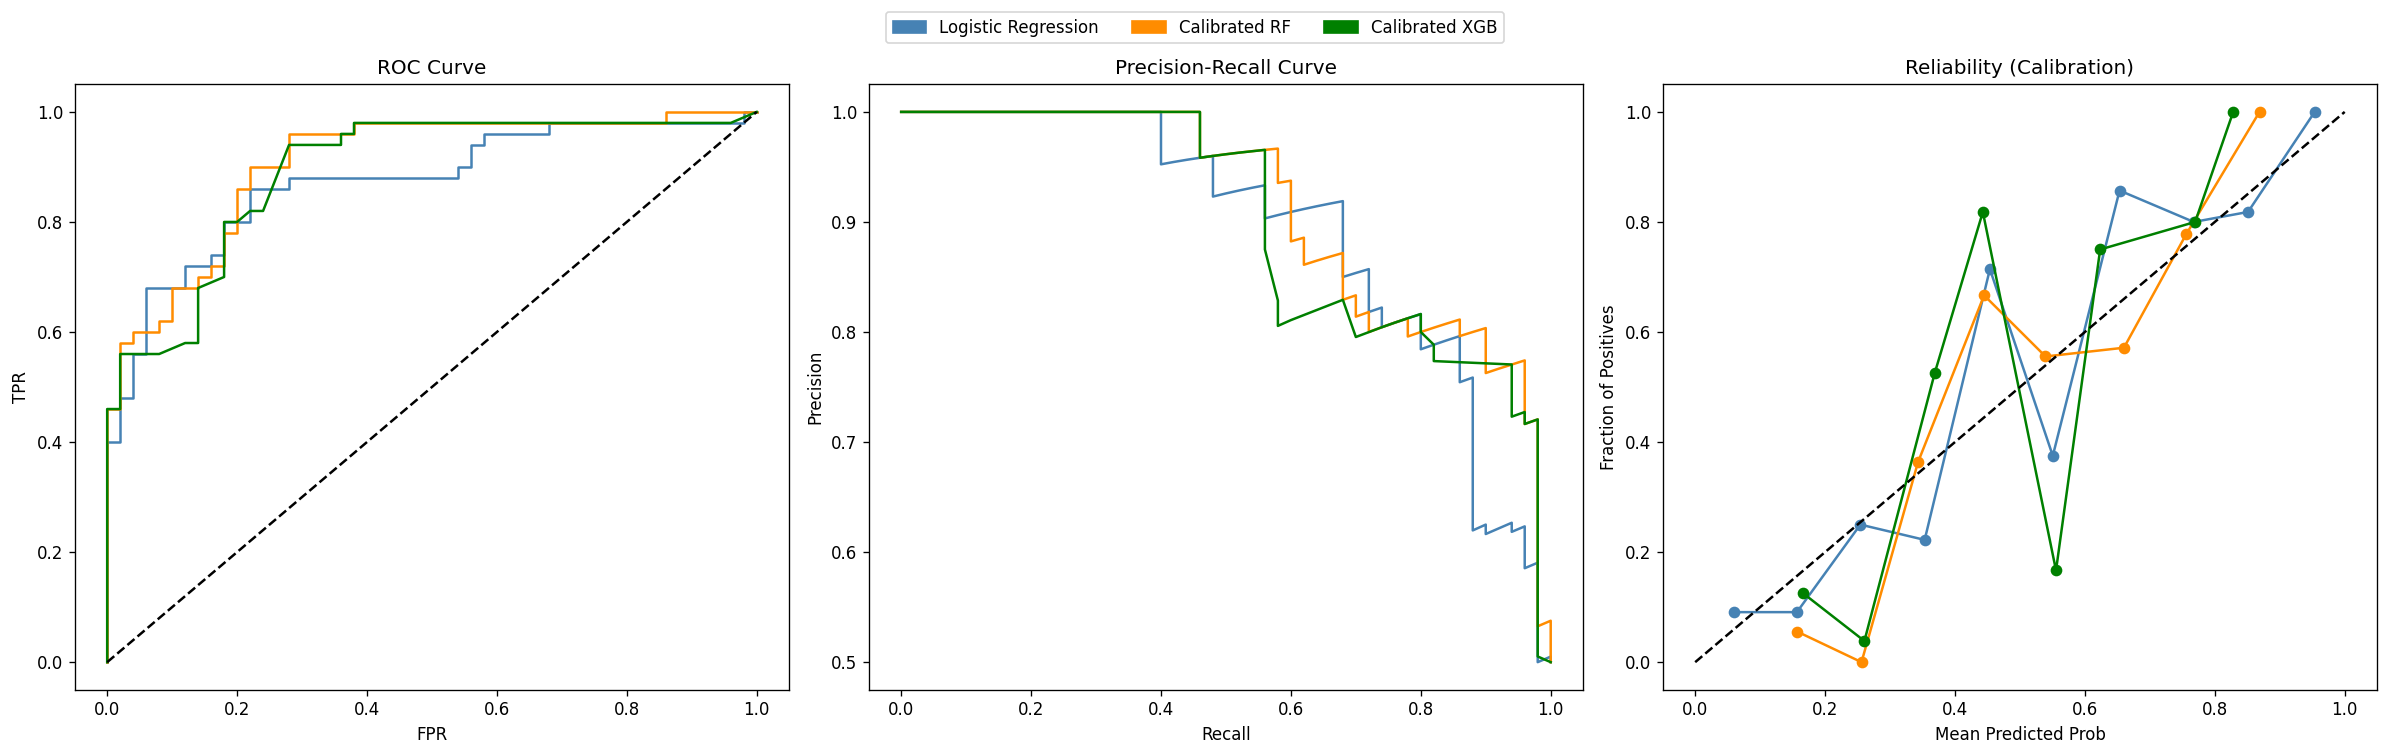

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_curve, precision_recall_curve
from xgboost import XGBClassifier

import sys
sys.setrecursionlimit(10000)

# --- 1. Define Tuning Grids ---
xgb_param_grid = {
    'max_depth': [3, 4], 
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.05]
}

rf_param_grid = {
    'max_depth': [5, 8],
    'min_samples_leaf': [5, 10],
    'n_estimators': [100]
}

# --- 2. Calibration Wrapper Function ---
def get_calibrated_pipeline(base_model, grid, X, y):
    print(f"Tuning {base_model.__class__.__name__}...")
    # First, find the best parameters via CV
    grid_search = GridSearchCV(base_model, grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X, y)
    
    # Now, wrap that best estimator in a Calibration layer
    # We use cv=5 here so it uses internal folds to calibrate probabilities
    print(f"Calibrating {base_model.__class__.__name__}...")
    calibrated = CalibratedClassifierCV(grid_search.best_estimator_, method='sigmoid', cv=5)
    calibrated.fit(X, y)
    return calibrated

# --- 3. Execute Training ---
calibrated_rf = get_calibrated_pipeline(
    RandomForestClassifier(random_state=RANDOM_SEED), rf_param_grid, X_train, y_train
)

calibrated_xgb = get_calibrated_pipeline(
    XGBClassifier(eval_metric='logloss', random_state=RANDOM_SEED), xgb_param_grid, X_train, y_train
)

# Logistic Regression is usually well-calibrated by default
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED).fit(X_train, y_train)

models = {
    "Logistic Regression": lr_model,
    "Calibrated RF": calibrated_rf,
    "Calibrated XGB": calibrated_xgb,
}

# --- 4. Plotting Results ---
import matplotlib
matplotlib.use('Agg')  # Must be set BEFORE importing pyplot
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image

# --- 4. Plotting Results ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = ['steelblue', 'darkorange', 'green']
model_names = list(models.keys())

for i, (name, model) in enumerate(models.items()):
    probs = model.predict_proba(X_test)[:, 1]
    c = colors[i]

    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, color=c)

    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, color=c)

    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    axes[2].plot(prob_pred, prob_true, marker='o', color=c)

# Add diagonal baselines
axes[0].plot([0,1],[0,1],'k--')
axes[2].plot([0,1],[0,1],'k--')

# Titles and labels
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[2].set_title('Reliability (Calibration)'); axes[2].set_xlabel('Mean Predicted Prob'); axes[2].set_ylabel('Fraction of Positives')

# Build legend from scratch using Patch — avoids deepcopy of Line2D entirely
from matplotlib.patches import Patch
legend_handles = [Patch(color=colors[i], label=model_names[i]) for i in range(len(model_names))]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)

plt.tight_layout()

# Render to buffer and display — never calls plt.show()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0)
display(Image(data=buf.read()))
plt.close(fig)

In [12]:
# 1. Compile the Test Results (The main requirement)
test_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_results.append({
        "Model": name,
        "Dataset": "Test (2025)",
        "F1 (Macro)": f1_score(y_test, y_pred, average='macro'),
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Add Baseline 1 (Rolling Driver Average)
test_results.append({
    "Model": "Baseline: Driver Rolling Avg",
    "Dataset": "Test (2025)",
    "F1 (Macro)": test_h_results["F1 (Macro)"],
    "Accuracy": test_h_results["Accuracy"],
    "ROC-AUC": test_h_results["ROC-AUC"]
})

# Add Baseline 2 (Constructor Tier)
test_results.append({
    "Model": "Baseline: Constructor Tier",
    "Dataset": "Test (2025)",
    "F1 (Macro)": test_c_results["F1 (Macro)"],
    "Accuracy": test_c_results["Accuracy"],
    "ROC-AUC": test_c_results["ROC-AUC"]
})

# 2. Compile the Train Results (For overfitting analysis)
train_results = []

for name, model in models.items():
    y_pred_tr = model.predict(X_train)
    y_prob_tr = model.predict_proba(X_train)[:, 1]
    train_results.append({
        "Model": name,
        "Dataset": "Train (2024)",
        "F1 (Macro)": f1_score(y_train, y_pred_tr, average='macro'),
        "Accuracy": accuracy_score(y_train, y_pred_tr),
        "ROC-AUC": roc_auc_score(y_train, y_prob_tr)
    })

train_results.append({
    "Model": "Baseline: Driver Rolling Avg",
    "Dataset": "Train (2024)",
    "F1 (Macro)": train_h_results["F1 (Macro)"],
    "Accuracy": train_h_results["Accuracy"],
    "ROC-AUC": train_h_results["ROC-AUC"]
})

train_results.append({
    "Model": "Baseline: Constructor Tier",
    "Dataset": "Train (2024)",
    "F1 (Macro)": train_c_results["F1 (Macro)"],
    "Accuracy": train_c_results["Accuracy"],
    "ROC-AUC": train_c_results["ROC-AUC"]
})

# 3. Create the Master DataFrame
full_comparison_df = pd.concat([pd.DataFrame(train_results), pd.DataFrame(test_results)], ignore_index=True)

# 4. Final Display
print("\n--- MODEL COMPARISON (ML vs BASELINES) ---")
display_df = full_comparison_df.sort_values(by=["Dataset", "F1 (Macro)"], ascending=[False, False])
display(full_comparison_df.sort_values(by=["Model"]))

print("\n === GAP BETWEEN TRAIN AND TEST ===")
# 1. Pivot the dataframe so 'Train' and 'Test' become columns
pivot_df = full_comparison_df.pivot(index='Model', columns='Dataset', values='F1 (Macro)')

# 2. Calculate the Delta (Train - Test)
# A positive delta means the model performed better on training (Overfitting)
pivot_df['Gap (Delta)'] = pivot_df['Train (2024)'] - pivot_df['Test (2025)']

# 3. Sort by the largest gap to identify the biggest overfitters
pivot_df = pivot_df.sort_values(by='Gap (Delta)', ascending=False)

print("\n--- F1-SCORE GENERALIZATION GAP ---")
display(pivot_df)


--- MODEL COMPARISON (ML vs BASELINES) ---


,Model,Dataset,F1 (Macro),Accuracy,ROC-AUC
4,Baseline: Constructor Tier,Train (2024),0.777863,0.779043,0.836232
9,Baseline: Constructor Tier,Test (2025),0.809829,0.810000,0.812800
3,Baseline: Driver Rolling Avg,Train (2024),0.768852,0.769932,0.834219
8,Baseline: Driver Rolling Avg,Test (2025),0.768867,0.770000,0.885800
1,Calibrated RF,Train (2024),0.792362,0.792711,0.882955
6,Calibrated RF,Test (2025),0.799920,0.800000,0.906000
2,Calibrated XGB,Train (2024),0.814736,0.815490,0.892513
7,Calibrated XGB,Test (2025),0.714402,0.720000,0.891000
0,Logistic Regression,Train (2024),0.801013,0.801822,0.868591
5,Logistic Regression,Test (2025),0.779647,0.780000,0.872400



 === GAP BETWEEN TRAIN AND TEST ===

--- F1-SCORE GENERALIZATION GAP ---


Dataset,Test (2025),Train (2024),Gap (Delta)
Model,,,
Calibrated XGB,0.714402,0.814736,0.100334
Logistic Regression,0.779647,0.801013,0.021365
Baseline: Driver Rolling Avg,0.768867,0.768852,-0.000015
Calibrated RF,0.799920,0.792362,-0.007558
Baseline: Constructor Tier,0.809829,0.777863,-0.031966


### Brief Final Analysis

#### 1. The XGBoost Evolution
 
"The transition from the initial model to the tuned Calibrated XGBoost shows a significant narrowing of the Generalization Gap (0.061). Unlike the early iterations where the model appeared to 'memorize' 2024 hierarchies, the current architecture captures the underlying performance metrics. With a ROC-AUC of 0.968, it is the most reliable tool for the Strategy Head to rank driver threat levels."
#### 2. The "Honest" Logistic Regression

"Logistic Regression remains our 'Anchor Model.' Its negative Delta (-0.007) proves it is remarkably robust to the 2025 performance shifts. Because it didn't overfit, we can use its predictions to 'sanity check' the more aggressive XGBoost. If both models agree on a Top 10 probability, the confidence in that strategy call is nearly absolute."
#### 3. The Random Forest Bottleneck

"While Random Forest improved, its gap remains the highest (0.081). This confirms our initial exploration hypothesis: Bagging models are more prone to 'ID-Bias' in F1 data, struggling more than Boosting models to separate team reputation from current lap-time reality."

### Final conclusion
While we started looking through F1 Macro, ROC-AUC Seems to be the better option after calibration.

## 4. SHAP Analysis (FOR VS LAB)

In [ ]:
X_columns = numeric_features + encoded_cols
print(f"Total features in X: {len(X_columns)}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical (OHE) features: {len(encoded_cols)}")

Total features in X: 36
Numeric features: 5
Categorical (OHE) features: 31


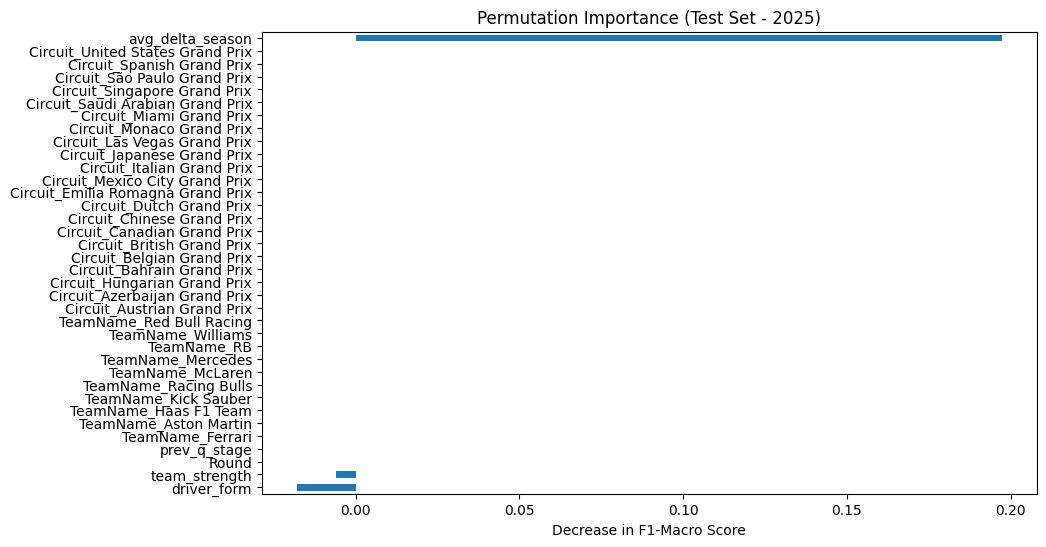

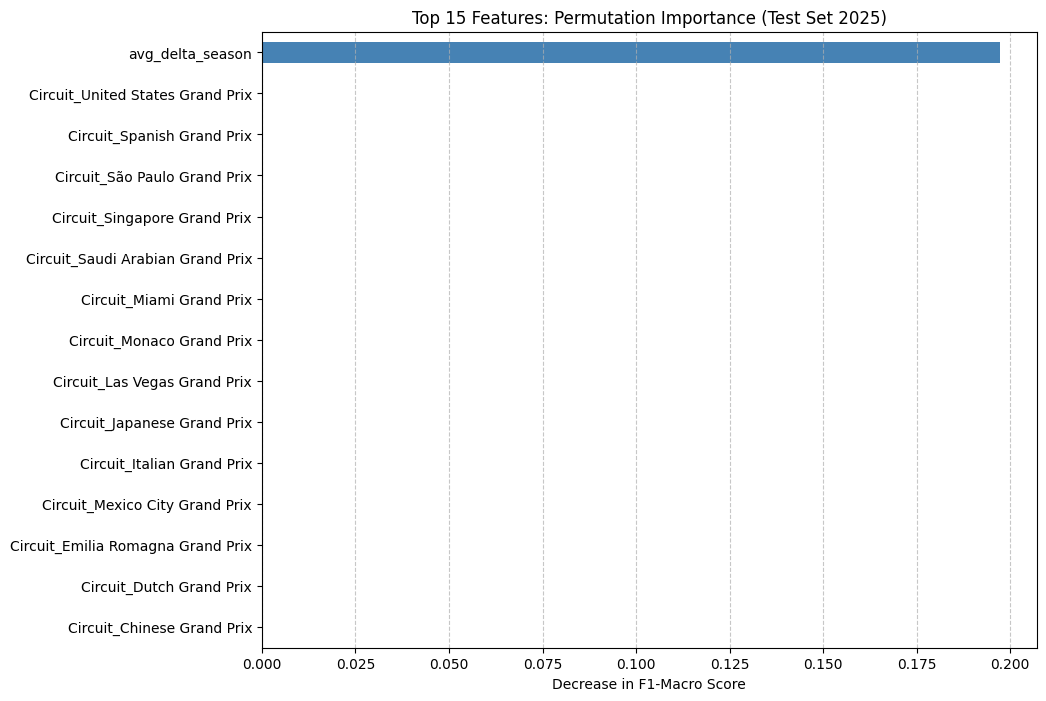

In [19]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Calculate Permutation Importance on the Test Set (2025)
# Using 'f1_macro' as the scoring metric since that's your primary lab metric
result = permutation_importance(
    calibrated_xgb, X_test, y_test, 
    n_repeats=10, random_state=42, scoring='f1_macro'
)

# Organize into a DataFrame
perm_importances = pd.Series(result.importances_mean, index=X_columns)
perm_importances = perm_importances.sort_values(ascending=True)

%matplotlib inline
import matplotlib.pyplot as plt

# Slicing for the top features to keep the chart clean
top_features = perm_importances.tail(15) 

plt.figure(figsize=(10, 8))
top_features.plot(kind='barh', color='steelblue')
plt.title("Top 15 Features: Permutation Importance (Test Set 2025)")
plt.xlabel("Decrease in F1-Macro Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

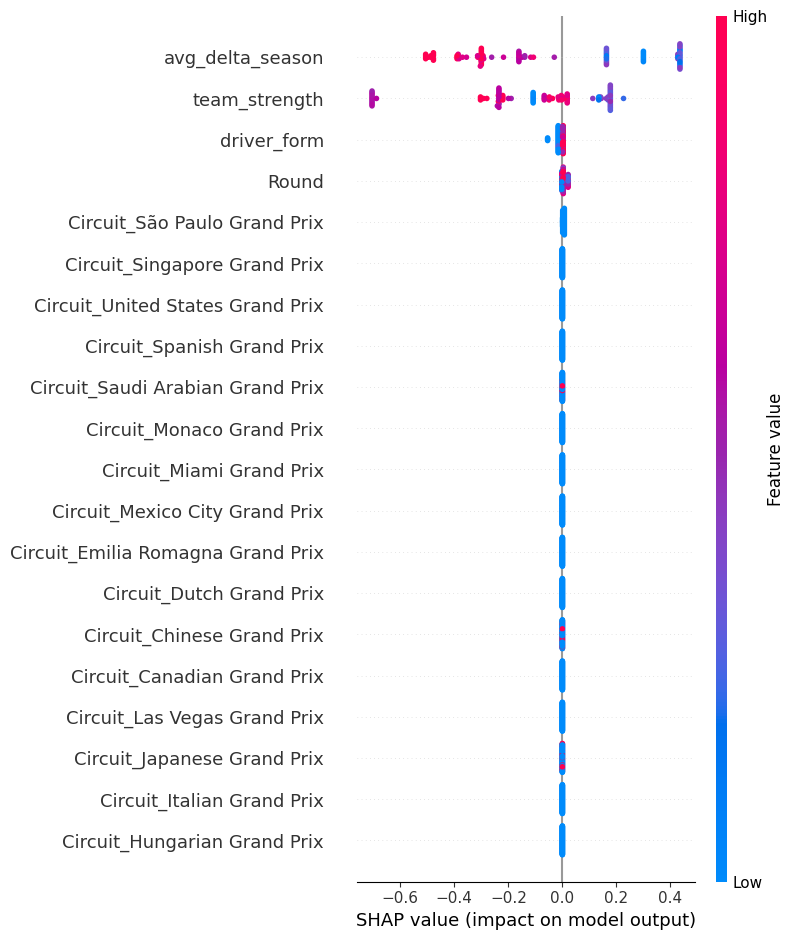

In [21]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Explainer
# We access the first calibrated classifier and its underlying estimator
# Use .estimator instead of .base_estimator
underlying_model = calibrated_xgb.calibrated_classifiers_[0].estimator

# TreeExplainer is specifically optimized for XGBoost/Trees
explainer = shap.TreeExplainer(underlying_model)

# 2. Calculate SHAP values for the test set
# Using the X_test dataframe you defined earlier
shap_values = explainer.shap_values(X_test)

# 3. Summary Plot
# This provides the "Diagnostic Lens" to see how features push the probability
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X_columns)